# Advanced Models - Week 7

This notebook tests LightGBM with the Week 6 features.
I only try a few parameter combinations so the tuning stays simple.
April 2026 is used for model selection, and May 2026 is the final test.

In [1]:
from pathlib import Path
import urllib.request

import geopandas as gpd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 42
TARGET = "ClosePrice"
VALIDATION_MONTH = "2026-04"
TEST_MONTH = "2026-05"
PROJECT_ROOT = Path("..") if Path("../data/week3_drive").exists() else Path(".")
DATA_DIR = PROJECT_ROOT / "data/week3_drive"
OUTPUT_DIR = PROJECT_ROOT / "outputs/week7_advanced_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "crmls_sfr_train_X12_2025-05_to_2026-04.csv"
TEST_FILE = DATA_DIR / "crmls_sfr_test_2026-05.csv"
SCHOOL_FILE = PROJECT_ROOT / "data/week6_reference/california_school_district_areas_2024_25.geojson"
SCHOOL_URL = (
    "https://gis.data.ca.gov/api/download/v1/items/"
    "b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
)


def find_file(local_path):
    if local_path.exists():
        return local_path
    drive_root = Path("/content/drive/MyDrive")
    if drive_root.exists():
        matches = list(drive_root.rglob(local_path.name))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {local_path.name}")


if not SCHOOL_FILE.exists():
    SCHOOL_FILE.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(SCHOOL_URL, SCHOOL_FILE)

## 1. Load and clean the data

In [2]:
history = pd.read_csv(find_file(TRAIN_FILE), low_memory=False)
test = pd.read_csv(find_file(TEST_FILE), low_memory=False)

NUMERIC_COLUMNS = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "YearBuilt", "Latitude", "Longitude", "AssociationFee", "Stories", "GarageSpaces",
]


def clean_data(data):
    data = data.copy()

    # Restore the missing values marked in Week 3.
    for column in NUMERIC_COLUMNS:
        missing_flag = f"{column}_was_missing"
        if missing_flag in data.columns:
            data.loc[data[missing_flag].fillna(False).astype(bool), column] = np.nan

    data[TARGET] = pd.to_numeric(data[TARGET], errors="coerce")
    data = data[data[TARGET].notna() & (data[TARGET] > 0)].copy()

    living_area = pd.to_numeric(data["LivingArea"], errors="coerce")
    data = data[~(living_area.notna() & (living_area <= 0))].copy()

    bedrooms = pd.to_numeric(data["BedroomsTotal"], errors="coerce")
    data = data[~(bedrooms.notna() & (bedrooms < 0))].copy()

    bathrooms = pd.to_numeric(data["BathroomsTotalInteger"], errors="coerce")
    data = data[~(bathrooms.notna() & (bathrooms < 0))].copy()

    close_date = pd.to_datetime(data["CloseDate"], errors="coerce")
    list_date = pd.to_datetime(data["ListingContractDate"], errors="coerce")
    data = data[~(close_date.notna() & list_date.notna() & (close_date < list_date))].copy()
    data = data.drop_duplicates(subset="ListingKey")
    return data


history = clean_data(history)
test = clean_data(test)
test = test[~test["ListingKey"].isin(history["ListingKey"])].copy()

print("History rows:", len(history))
print("Test rows:", len(test))

History rows: 129669
Test rows: 12008


## 2. Add the Week 6 features

In [3]:
DISTRICT_COLUMNS = [
    "SchoolDistrictElementary",
    "SchoolDistrictHigh",
    "SchoolDistrictUnified",
]


def make_district_lookup(data_list):
    coordinates = pd.concat(
        [data[["Latitude", "Longitude"]] for data in data_list],
        ignore_index=True,
    )
    coordinates = coordinates.apply(pd.to_numeric, errors="coerce")
    coordinates = coordinates.dropna().drop_duplicates().reset_index(drop=True)
    coordinates["coordinate_id"] = coordinates.index

    points = gpd.GeoDataFrame(
        coordinates,
        geometry=gpd.points_from_xy(coordinates["Longitude"], coordinates["Latitude"]),
        crs="EPSG:4326",
    )
    districts = gpd.read_file(
        SCHOOL_FILE,
        columns=["DistrictName", "DistrictType", "geometry"],
    )
    joined = gpd.sjoin(points, districts, how="left", predicate="intersects")

    type_names = {
        "Elementary": "SchoolDistrictElementary",
        "High": "SchoolDistrictHigh",
        "Unified": "SchoolDistrictUnified",
    }
    joined["district_column"] = joined["DistrictType"].map(type_names)
    joined = joined.dropna(subset=["district_column", "DistrictName"])

    lookup = joined.pivot_table(
        index="coordinate_id",
        columns="district_column",
        values="DistrictName",
        aggfunc="first",
    )
    lookup = coordinates.join(lookup, on="coordinate_id")
    for column in DISTRICT_COLUMNS:
        if column not in lookup.columns:
            lookup[column] = np.nan
    return lookup[["Latitude", "Longitude"] + DISTRICT_COLUMNS]


district_lookup = make_district_lookup([history, test])


def add_features(data):
    data = data.copy()
    data["Latitude"] = pd.to_numeric(data["Latitude"], errors="coerce")
    data["Longitude"] = pd.to_numeric(data["Longitude"], errors="coerce")
    data = data.merge(district_lookup, on=["Latitude", "Longitude"], how="left")

    sale_month = pd.to_datetime(data["close_month"], errors="coerce")
    year_built = pd.to_numeric(data["YearBuilt"], errors="coerce")
    bedrooms = pd.to_numeric(data["BedroomsTotal"], errors="coerce")
    bathrooms = pd.to_numeric(data["BathroomsTotalInteger"], errors="coerce")

    data["PropertyAge"] = sale_month.dt.year - year_built
    data["PropertyAge"] = data["PropertyAge"].where(data["PropertyAge"] >= 0)
    data["BedBathRatio"] = (bedrooms / bathrooms).where(bathrooms > 0)
    data["SaleMonthSin"] = np.sin(2 * np.pi * sale_month.dt.month / 12)
    data["SaleMonthCos"] = np.cos(2 * np.pi * sale_month.dt.month / 12)
    return data


history = add_features(history)
test = add_features(test)

NUMERIC_FEATURES = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "Latitude", "Longitude", "AssociationFee", "Stories", "GarageSpaces",
    "PropertyAge", "BedBathRatio", "SaleMonthSin", "SaleMonthCos",
]
CATEGORICAL_FEATURES = [
    "PostalCode", "City", "PropertySubType",
] + DISTRICT_COLUMNS

## 3. Create the LightGBM model

In [4]:
def make_model(max_depth, learning_rate, n_estimators):
    preprocessing = ColumnTransformer([
        ("numeric", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
        ]), CATEGORICAL_FEATURES),
    ])

    model = lgb.LGBMRegressor(
        max_depth=max_depth,
        num_leaves=min(2 ** max_depth, 127),
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", model),
    ])


def metrics(y_true, y_pred):
    percentage_error = np.abs((np.asarray(y_true) - y_pred) / np.asarray(y_true))
    return {
        "r2": r2_score(y_true, y_pred),
        "mape": percentage_error.mean(),
        "mdape": np.median(percentage_error),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
    }


def remove_price_outliers(train_data, other_data):
    lower = train_data[TARGET].quantile(0.005)
    upper = train_data[TARGET].quantile(0.995)
    train_data = train_data[train_data[TARGET].between(lower, upper)].copy()
    other_data = other_data[other_data[TARGET].between(lower, upper)].copy()
    return train_data, other_data

## 4. Light hyperparameter tuning on April 2026

I test two tree depths, two learning rates, and two estimator counts.
Only four simple combinations are used.

In [5]:
development = history[history["close_month"] < VALIDATION_MONTH].copy()
validation = history[history["close_month"] == VALIDATION_MONTH].copy()
development, validation = remove_price_outliers(development, validation)

parameter_options = [
    {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 400},
    {"max_depth": 8, "learning_rate": 0.05, "n_estimators": 400},
    {"max_depth": 6, "learning_rate": 0.10, "n_estimators": 250},
    {"max_depth": 8, "learning_rate": 0.10, "n_estimators": 250},
]

tuning_rows = []
for params in parameter_options:
    model = make_model(**params)
    model.fit(development, development[TARGET])
    predictions = model.predict(validation)
    tuning_rows.append({**params, **metrics(validation[TARGET], predictions)})

tuning_results = pd.DataFrame(tuning_rows).sort_values("mdape").reset_index(drop=True)
display(tuning_results.round(4))

best_params = {
    "max_depth": int(tuning_results.iloc[0]["max_depth"]),
    "learning_rate": float(tuning_results.iloc[0]["learning_rate"]),
    "n_estimators": int(tuning_results.iloc[0]["n_estimators"]),
}
print("Best parameters:", best_params)

,max_depth,learning_rate,n_estimators,r2,mape,mdape,mae,rmse
0,8,0.10,250,0.8748,0.1518,0.1034,187629.0161,350373.9352
1,8,0.05,400,0.8718,0.1569,0.1079,192514.8155,354525.8078
2,6,0.10,250,0.8612,0.1703,0.1224,205533.8640,368915.5099
3,6,0.05,400,0.8578,0.1749,0.1246,210014.6068,373385.4856


Best parameters: {'max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 250}


## 5. Final test on May 2026

In [6]:
final_train, final_test = remove_price_outliers(history, test)
final_model = make_model(**best_params)
final_model.fit(final_train, final_train[TARGET])
final_predictions = final_model.predict(final_test)

test_metrics = pd.DataFrame([
    {
        "model": "LightGBM",
        **best_params,
        **metrics(final_test[TARGET], final_predictions),
    }
])
display(test_metrics.round(4))

,model,max_depth,learning_rate,n_estimators,r2,mape,mdape,mae,rmse
0,LightGBM,8,0.1,250,0.8758,0.147,0.1042,186876.0616,351185.9071


## 6. Save and show the results

In [7]:
tuning_results.to_csv(OUTPUT_DIR / "lightgbm_tuning_results.csv", index=False)
test_metrics.to_csv(OUTPUT_DIR / "lightgbm_test_metrics.csv", index=False)

prediction_table = pd.DataFrame({
    "ListingKey": final_test["ListingKey"],
    "actual_price": final_test[TARGET],
    "predicted_price": final_predictions,
})
prediction_table.to_csv(OUTPUT_DIR / "lightgbm_test_predictions.csv", index=False)

# Week 6 Random Forest results are included as a reference.
comparison = pd.DataFrame([
    {"model": "Week 6 Random Forest", "r2": 0.8668625, "mdape": 0.0829328},
    {"model": "Week 7 LightGBM", "r2": test_metrics.loc[0, "r2"],
     "mdape": test_metrics.loc[0, "mdape"]},
])
comparison.to_csv(OUTPUT_DIR / "week6_vs_week7.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#8da0cb", "#66c2a5"]
axes[0].bar(comparison["model"], comparison["r2"], color=colors)
axes[0].set_title("May 2026 Test R2")
axes[0].set_ylim(0, 1)
for index, value in enumerate(comparison["r2"]):
    axes[0].text(index, value + 0.02, f"{value:.3f}", ha="center")

axes[1].bar(comparison["model"], comparison["mdape"] * 100, color=colors)
axes[1].set_title("May 2026 Test MdAPE")
axes[1].set_ylabel("MdAPE (%)")
for index, value in enumerate(comparison["mdape"]):
    axes[1].text(index, value * 100 + 0.2, f"{value:.2%}", ha="center")

for axis in axes:
    axis.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "week7_test_results.png", dpi=160)
plt.close()

## Final result

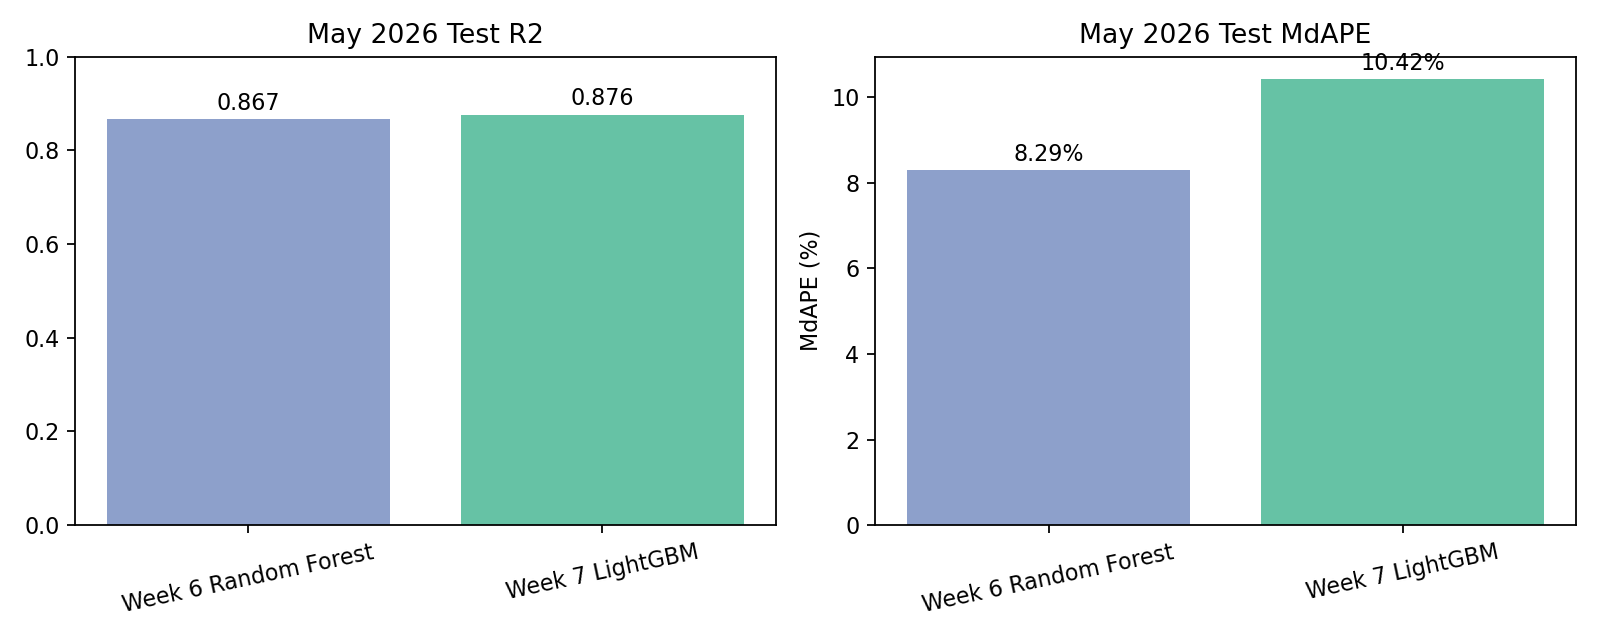

In [8]:
display(Image(filename=OUTPUT_DIR / "week7_test_results.png"))

## Conclusion

Week 7 tests LightGBM as an advanced gradient boosting model. The best settings
are selected using April 2026 only. The selected model is then retrained with all
available history and evaluated once on the May 2026 test set.